## 1. Imports

In [113]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split

In [167]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
import joblib

## 2. Data Split and Normalization

In [115]:
df = pd.read_csv('data/clean_dataset.csv')

In [116]:
x = df.drop(columns = ['stress_level'])
y = df['stress_level']

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size = 0.3, random_state = 42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size = 0.5, random_state = 42
)

In [117]:
FEATURE_COLS = x_train.columns.tolist()
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')

['models/feature_cols.pkl']

In [118]:
scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_val = scaler.transform(x_val)
X_test = scaler.transform(x_test)

In [119]:
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

## 3. Baseline model

In [ ]:
model_baseline = Sequential([
    Dense(32, activation = 'relu', input_shape = (x_train.shape[1],)),
    Dense(16, activation = 'relu'),
    Dense(1)
])

c:\Users\andre\stress-prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [128]:
model_baseline.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [129]:
history = model_baseline.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 100,
    batch_size = 64
)

Epoch 1/100


158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 20.5142 - mae: 3.5598 - val_loss: 1.8668 - val_mae: 1.0834
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5561 - mae: 0.9919 - val_loss: 1.2429 - val_mae: 0.8877
Epoch 3/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1359 - mae: 0.8479 - val_loss: 0.9333 - val_mae: 0.7722
Epoch 4/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8621 - mae: 0.7371 - val_loss: 0.7674 - val_mae: 0.6971
Epoch 5/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7085 - mae: 0.6678 - val_loss: 0.6628 - val_mae: 0.6442
Epoch 6/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6175 - mae: 0.6235 - val_loss: 0.5990 - val_mae: 0.6122
Epoch 7/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5607 - mae: 0.5936 - val_loss: 0.5547 - val_mae: 0.5897
Epoch 8/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5212 - mae: 0.5713 - val_loss: 0.5230 - val_mae: 0.5708
Epoch 9/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

In [130]:
def visualizar_graficas(history):
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    eps = range(1, len(mae) + 1)

    # MAE
    plt.plot(eps, mae, 'r', label='train MAE')
    plt.plot(eps, val_mae, 'b', label='validation MAE')
    plt.title('Train MAE vs. Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()

    plt.figure()

    # Loss (MSE)
    plt.plot(eps, loss, 'r', label='training loss (MSE)')
    plt.plot(eps, val_loss, 'b', label='validation loss (MSE)')
    plt.title('Train Loss vs. Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.legend()

    plt.show()

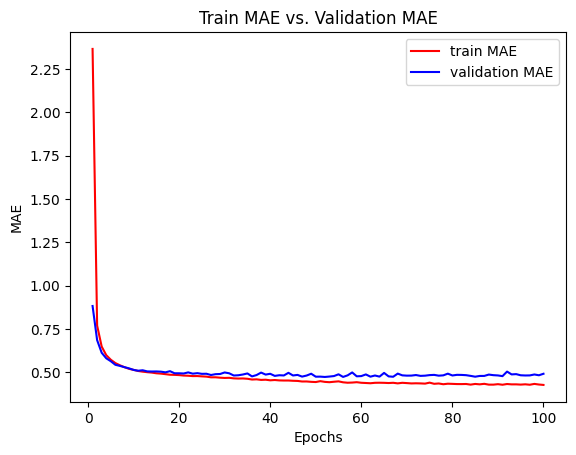

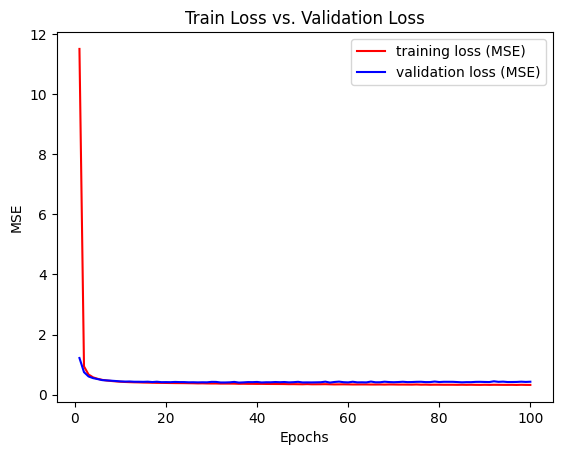

In [124]:
visualizar_graficas(history)

In [125]:
model_baseline.save('models/model_baseline.keras')

In [135]:
def real_vs_pred(y_true, y_pred):
    plt.scatter(y_test, y_pred, alpha = 0.5)
    plt.xlabel('Real Values')
    plt.ylabel('Predicted Values')
    plt.title('Real vs Predicted Values (Baseline Model)')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw = 2)
    plt.show()

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step


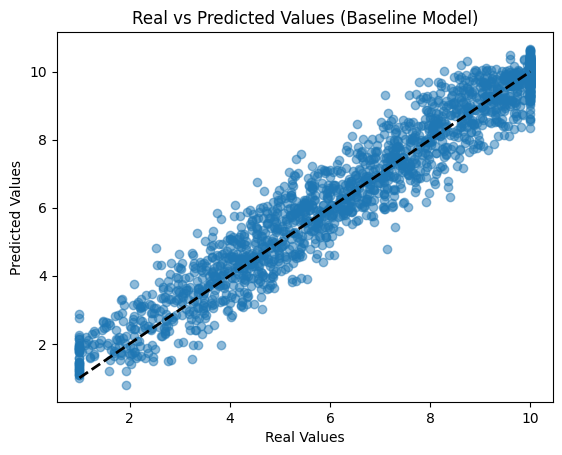

In [136]:
# Graficar valores de test vs predicciones
y_pred_baseline = model_baseline.predict(X_test).flatten()
real_vs_pred(y_test, y_pred_baseline)


## 4. Refinement

In [209]:
df2 = pd.read_csv('data/clean_dataset.csv')

x2 = df2.drop(columns = ['stress_level'])
y2 = df2['stress_level']

x_train2, x_temp2, y_train2, y_temp2 = train_test_split(
    x2, y2, test_size = 0.3, random_state = 42
)

x_val2, x_test2, y_val2, y_test2 = train_test_split(
    x_temp2, y_temp2, test_size = 0.5, random_state = 42
)

In [210]:
X_train2 = scaler.fit_transform(x_train2)
X_val2 = scaler.transform(x_val2)
X_test2 = scaler.transform(x_test2)

In [211]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train2.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

c:\Users\andre\stress-prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [212]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

In [213]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [214]:
history2 = model.fit(
    X_train2, y_train2,
    validation_data = (X_val2, y_val2),
    epochs = 150
)

Epoch 1/150


316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 12.6584 - mae: 2.7327 - val_loss: 1.3875 - val_mae: 0.9593
Epoch 2/150
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.0446 - mae: 1.1420 - val_loss: 0.7210 - val_mae: 0.6701
Epoch 3/150
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7245 - mae: 1.0491 - val_loss: 0.6292 - val_mae: 0.6208
Epoch 4/150
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4798 - mae: 0.9696 - val_loss: 0.5743 - val_mae: 0.5942
Epoch 5/150
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3492 - mae: 0.9303 - val_loss: 0.5265 - val_mae: 0.5627
Epoch 6/150
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3038 - mae: 0.9098 - val_loss: 0.5092 - val_mae: 0.5583
Epoch 7/150
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2360 - mae: 0.8851 - val_loss: 0.4940 - val_mae: 0.5491
Epoch 8/150
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1450 - mae: 0.8503 - val_loss: 0.4725 - val_mae: 0.5322
Epoch 9/150
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss

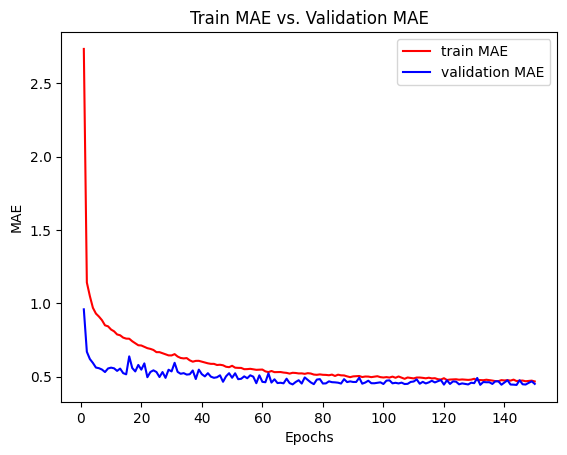

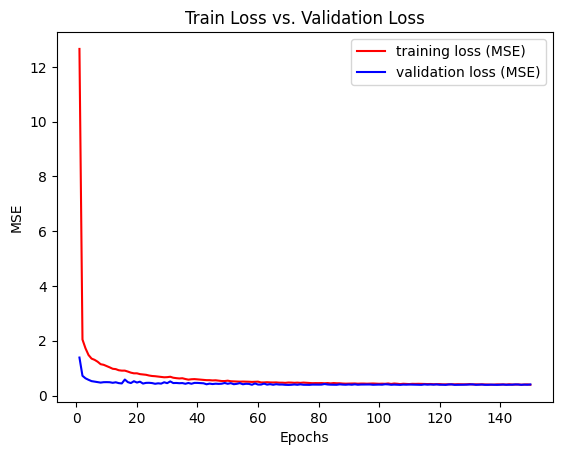

In [215]:
visualizar_graficas(history2)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


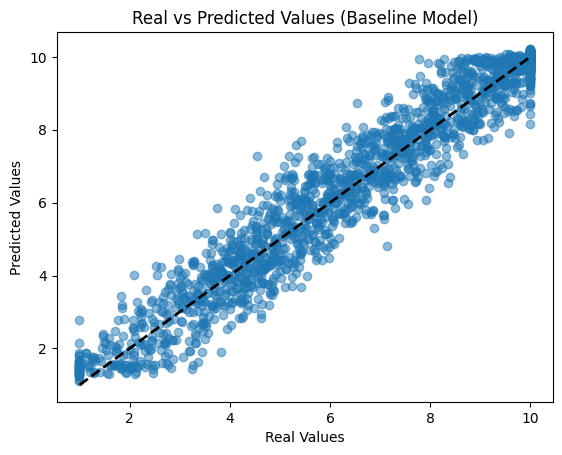

In [216]:
y_pred_2 = model.predict(X_test2).flatten()
real_vs_pred(y_test2, y_pred_2)

In [217]:
model.save('models/model_improved.keras')